# Data Scientist Nanodegree

## Convolutional Neural Networks

## Project: Write an Algorithm for a Dog Identification App 


This notebook walks you through one of the most popular Udacity projects across machine learning and artificial intellegence nanodegree programs.  The goal is to classify images of dogs according to their breed.  

If you are looking for a more guided capstone project related to deep learning and convolutional neural networks, this might be just it.  Notice that even if you follow the notebook to creating your classifier, you must still create a blog post or deploy an application to fulfill the requirements of the capstone project.

Also notice, you may be able to use only parts of this notebook (for example certain coding portions or the data) without completing all parts and still meet all requirements of the capstone project.

---

In this notebook, some template code has already been provided for you, and you will need to implement additional functionality to successfully complete this project. You will not need to modify the included code beyond what is requested. Sections that begin with **'(IMPLEMENTATION)'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section, and the specifics of the implementation are marked in the code block with a 'TODO' statement. Please be sure to read the instructions carefully! 

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut.  Markdown cells can be edited by double-clicking the cell to enter edit mode.

The rubric contains _optional_ "Stand Out Suggestions" for enhancing the project beyond the minimum requirements. If you decide to pursue the "Stand Out Suggestions", you should include the code in this IPython notebook.



---
### Why We're Here 

In this notebook, you will make the first steps towards developing an algorithm that could be used as part of a mobile or web app.  At the end of this project, your code will accept any user-supplied image as input.  If a dog is detected in the image, it will provide an estimate of the dog's breed.  If a human is detected, it will provide an estimate of the dog breed that is most resembling.  The image below displays potential sample output of your finished project (... but we expect that each student's algorithm will behave differently!). 

![Sample Dog Output](images/sample_dog_output.png)

In this real-world setting, you will need to piece together a series of models to perform different tasks; for instance, the algorithm that detects humans in an image will be different from the CNN that infers dog breed.  There are many points of possible failure, and no perfect algorithm exists.  Your imperfect solution will nonetheless create a fun user experience!

### The Road Ahead

We break the notebook into separate steps.  Feel free to use the links below to navigate the notebook.

* [Step 0](#step0): Import Datasets
* [Step 1](#step1): Detect Humans
* [Step 2](#step2): Detect Dogs
* [Step 3](#step3): Create a CNN to Classify Dog Breeds (from Scratch)
* [Step 4](#step4): Use a CNN to Classify Dog Breeds (using Transfer Learning)
* [Step 5](#step5): Create a CNN to Classify Dog Breeds (using Transfer Learning)
* [Step 6](#step6): Write your Algorithm
* [Step 7](#step7): Test Your Algorithm

---
<a id='step0'></a>
## Step 0: Import Datasets

### Import Dog Dataset

In the code cell below, we import a dataset of dog images.  We populate a few variables through the use of the `load_files` function from the scikit-learn library:
- `train_files`, `valid_files`, `test_files` - numpy arrays containing file paths to images
- `train_targets`, `valid_targets`, `test_targets` - numpy arrays containing onehot-encoded classification labels 
- `dog_names` - list of string-valued dog breed names for translating labels

In [1]:
# Run the following cell only if the /workspace/home/dog-project/dog_images/ folder is not present in your workspace.
# The cell below will copy the data to your /workspace directory. 
!cp -rp /data/dog_images/ /workspace/home/dog-project

'''
NOTE
There is a known "Permission denied" issue with copying the following files. You can ignore them.
- Ibizan_hound_05697.jpg
- American_foxhound_00503.jpg
- Basset_hound_01064.jpg
- Labrador_retriever_06476.jpg
- Manchester_terrier_06806.jpg
- Norwegian_lundehund_07217.jpg
'''

cp: cannot open '/data/dog_images/test/083.Ibizan_hound/Ibizan_hound_05697.jpg' for reading: Permission denied
cp: cannot open '/data/dog_images/train/007.American_foxhound/American_foxhound_00503.jpg' for reading: Permission denied
cp: cannot open '/data/dog_images/train/015.Basset_hound/Basset_hound_01064.jpg' for reading: Permission denied
cp: cannot open '/data/dog_images/train/096.Labrador_retriever/Labrador_retriever_06476.jpg' for reading: Permission denied
cp: cannot open '/data/dog_images/train/102.Manchester_terrier/Manchester_terrier_06806.jpg' for reading: Permission denied
cp: cannot open '/data/dog_images/train/110.Norwegian_lundehund/Norwegian_lundehund_07217.jpg' for reading: Permission denied


'\nNOTE\nThere is a known "Permission denied" issue with copying the following files. You can ignore them.\n- Ibizan_hound_05697.jpg\n- American_foxhound_00503.jpg\n- Basset_hound_01064.jpg\n- Labrador_retriever_06476.jpg\n- Manchester_terrier_06806.jpg\n- Norwegian_lundehund_07217.jpg\n'

In [2]:
# Install the necessary package
# Restart the kernel once after install this package
!python3 -m pip install opencv-python-headless==4.9.0.80

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
from sklearn.datasets import load_files       
from keras.utils import to_categorical
import numpy as np
from glob import glob

# Define function to load train, test, and validation datasets
def load_dataset(path):
    data = load_files(path)
    dog_files = data['filenames']
    dog_targets = to_categorical(np.array(data['target']), 133)
    return dog_files, dog_targets

# Load train, test, and validation datasets
train_files, train_targets = load_dataset('/workspace/home/dog-project/dogimages/dogImages/train')
valid_files, valid_targets = load_dataset('/workspace/home/dog-project/dogimages/dogImages/valid')
test_files, test_targets = load_dataset('/workspace/home/dog-project/dogimages/dogImages/test')

# Load list of dog names
dog_names = [item[20:-1] for item in sorted(glob("/workspace/home/dog-project/dog_images/train/*/"))]

# Print statistics about the dataset
print(f'There are {len(dog_names)} total dog categories.')
print(f'There are {len(train_files) + len(valid_files) + len(test_files)} total dog images.')
print(f'There are {len(train_files)} training dog images.')
print(f'There are {len(valid_files)} validation dog images.')
print(f'There are {len(test_files)} test dog images.')
print(len(train_targets))

2026-04-17 09:38:44.361707: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-17 09:38:44.361767: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-17 09:38:44.361845: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-17 09:38:44.374519: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


There are 133 total dog categories.
There are 8351 total dog images.
There are 6680 training dog images.
There are 835 validation dog images.
There are 836 test dog images.
6680


In [4]:
print(dog_names)

['project/dog_images/train/001.Affenpinscher', 'project/dog_images/train/002.Afghan_hound', 'project/dog_images/train/003.Airedale_terrier', 'project/dog_images/train/004.Akita', 'project/dog_images/train/005.Alaskan_malamute', 'project/dog_images/train/006.American_eskimo_dog', 'project/dog_images/train/007.American_foxhound', 'project/dog_images/train/008.American_staffordshire_terrier', 'project/dog_images/train/009.American_water_spaniel', 'project/dog_images/train/010.Anatolian_shepherd_dog', 'project/dog_images/train/011.Australian_cattle_dog', 'project/dog_images/train/012.Australian_shepherd', 'project/dog_images/train/013.Australian_terrier', 'project/dog_images/train/014.Basenji', 'project/dog_images/train/015.Basset_hound', 'project/dog_images/train/016.Beagle', 'project/dog_images/train/017.Bearded_collie', 'project/dog_images/train/018.Beauceron', 'project/dog_images/train/019.Bedlington_terrier', 'project/dog_images/train/020.Belgian_malinois', 'project/dog_images/train/0

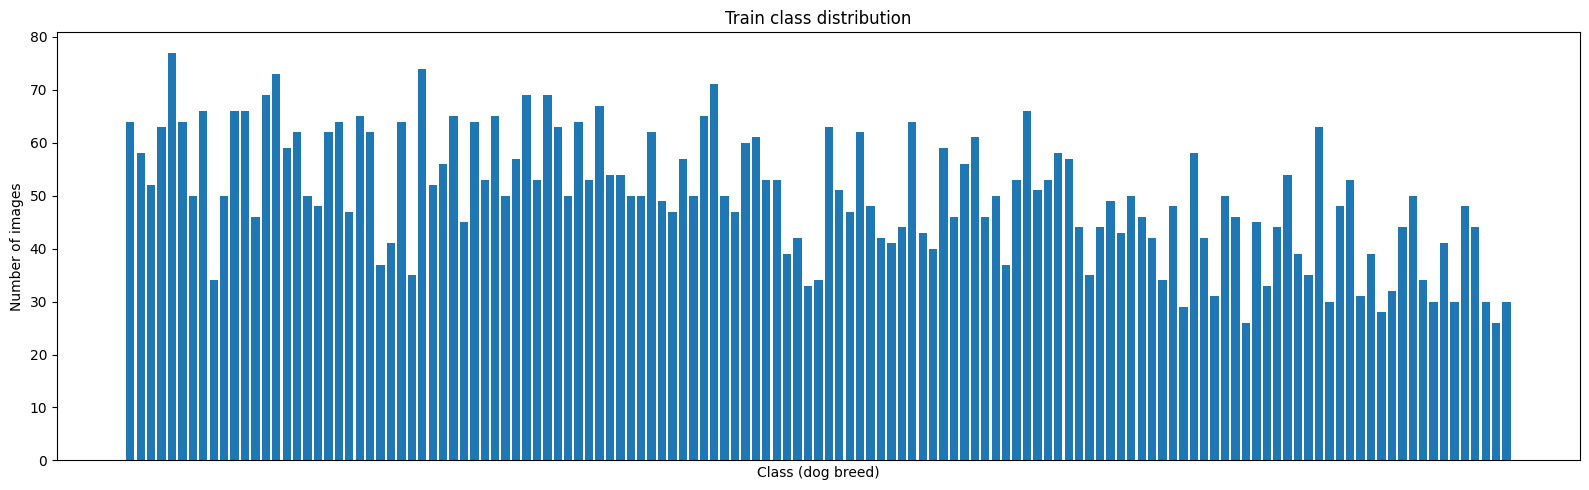

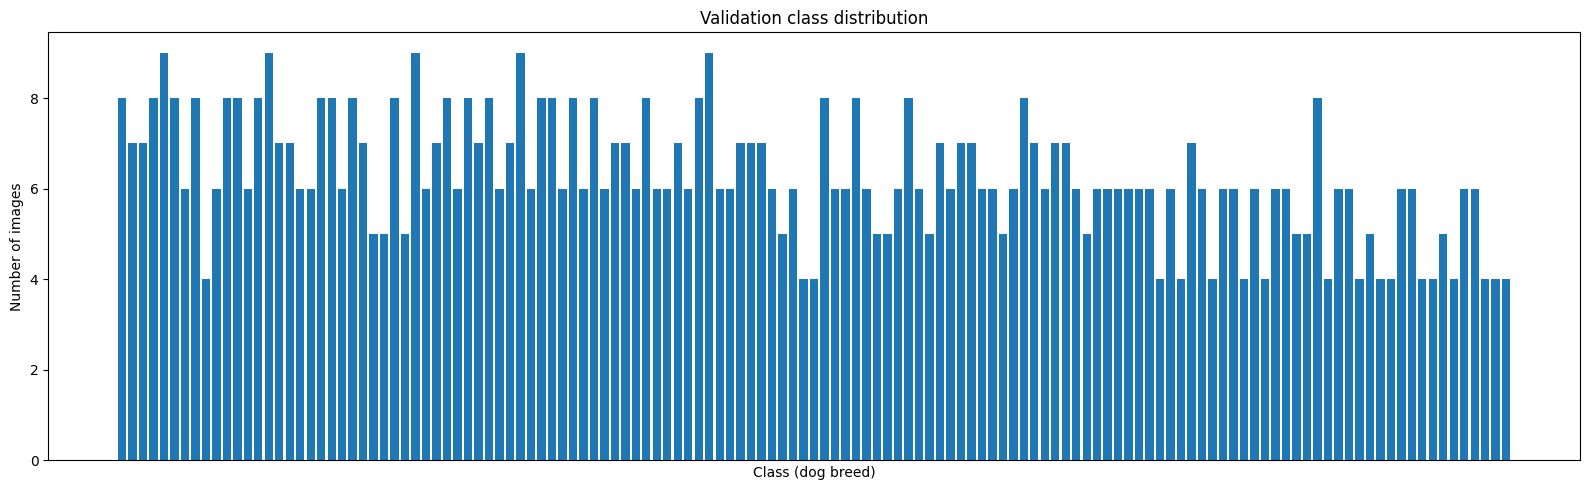

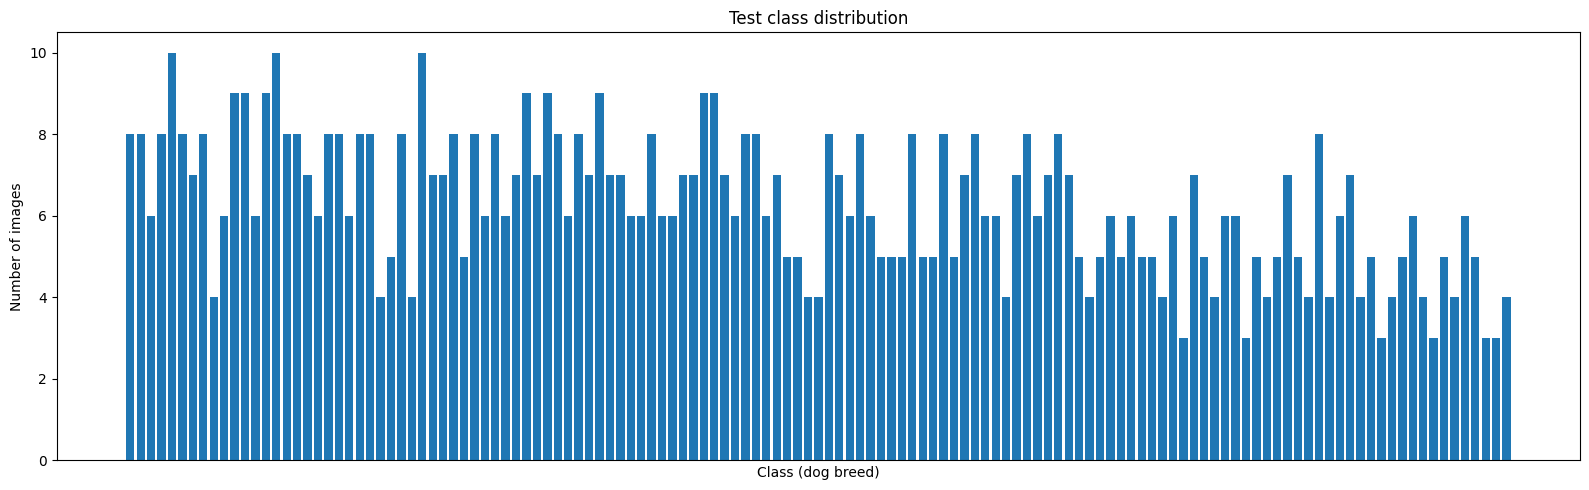

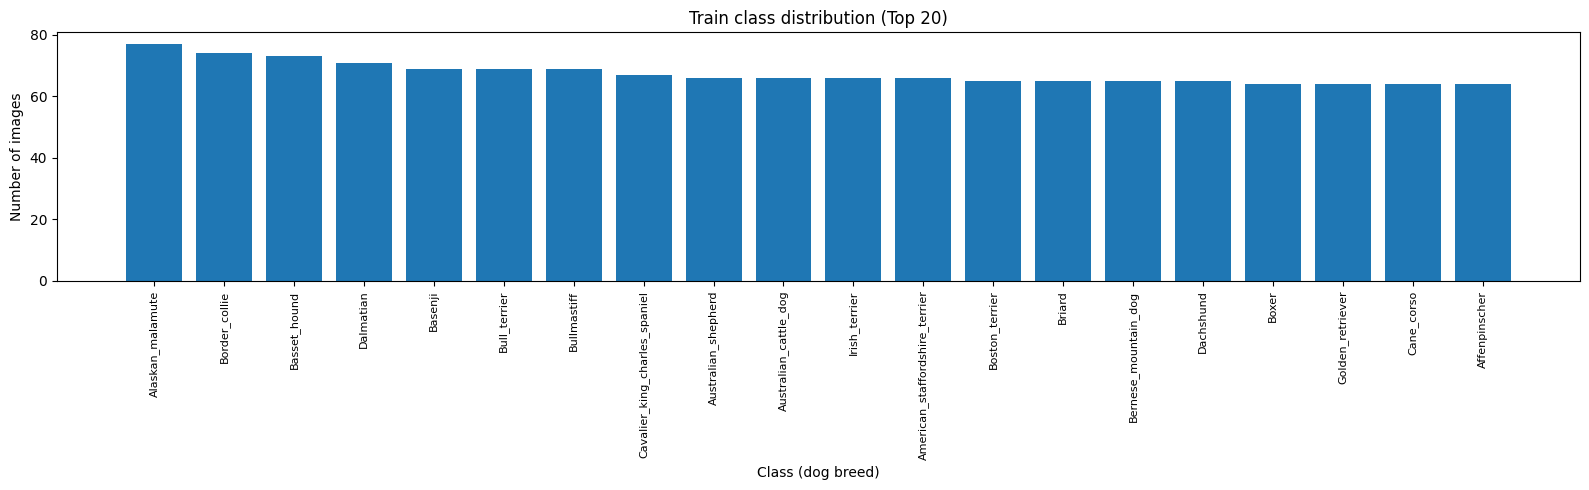

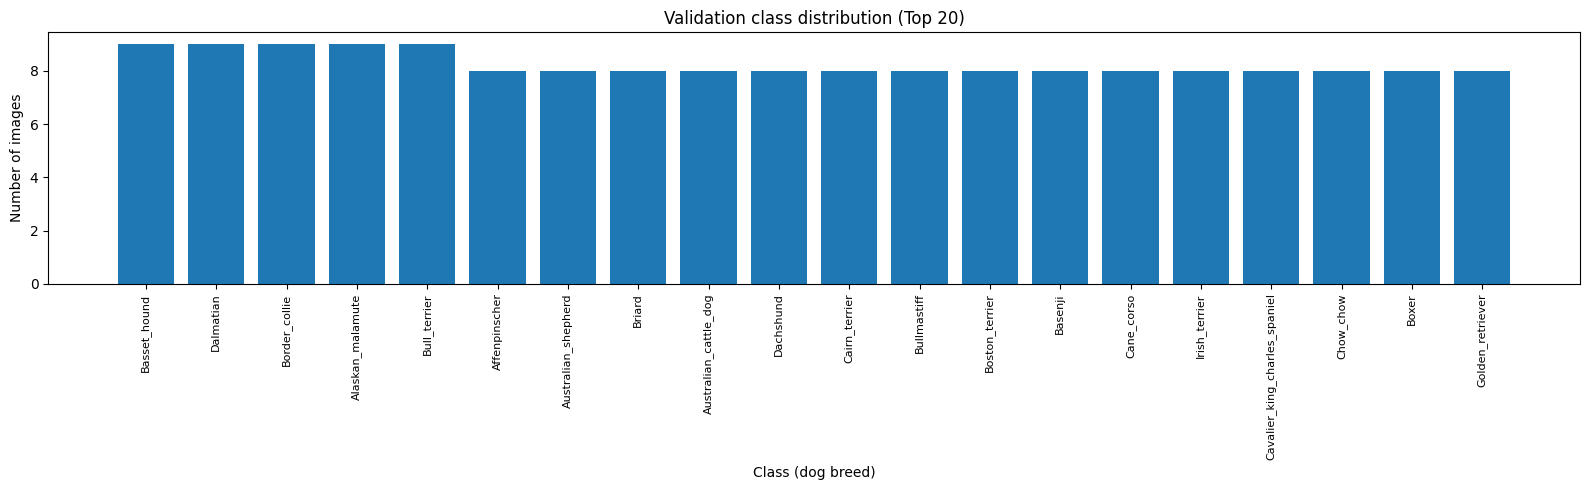

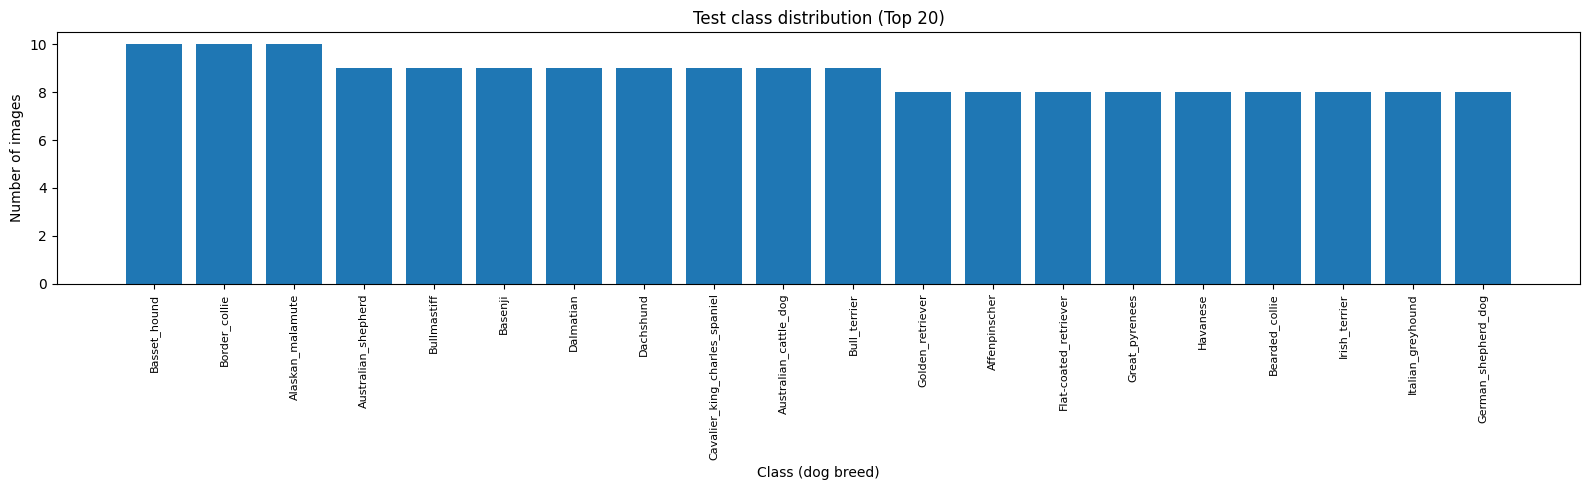

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def plot_class_distribution(targets_onehot, class_names, title="", top_n=None, show_labels=False):
    """
    Plot class counts from one-hot encoded targets.
    
    Args:
        targets_onehot (np.ndarray): shape (N, num_classes) one-hot labels
        class_names (list): list of class names length num_classes
        title (str): plot title
        top_n (int|None): if set, only plot top_n most frequent classes
        show_labels (bool): whether to show x-tick labels (crowded for 133 classes)
    """
    # Convert one-hot -> class indices
    y = np.argmax(targets_onehot, axis=1)
    counts = np.bincount(y, minlength=len(class_names))
    
    # Optionally select top_n classes
    if top_n is not None:
        idx = np.argsort(counts)[::-1][:top_n]
        counts_to_plot = counts[idx]
        names_to_plot = [class_names[i] for i in idx]
    else:
        idx = np.arange(len(class_names))
        counts_to_plot = counts
        names_to_plot = class_names

    plt.figure(figsize=(16, 5))
    plt.bar(np.arange(len(counts_to_plot)), counts_to_plot)
    plt.title(title)
    plt.ylabel("Number of images")
    plt.xlabel("Class (dog breed)")
    
    if show_labels:
        plt.xticks(np.arange(len(counts_to_plot)), names_to_plot, rotation=90, fontsize=8)
    else:
        plt.xticks([])  # hide crowded labels
    
    plt.tight_layout()
    plt.show()

# --- Plot each split separately ---
plot_class_distribution(train_targets, dog_names, title="Train class distribution", top_n=None, show_labels=False)
plot_class_distribution(valid_targets, dog_names, title="Validation class distribution", top_n=None, show_labels=False)
plot_class_distribution(test_targets, dog_names, title="Test class distribution", top_n=None, show_labels=False)

# --- Top 20 ---
plot_class_distribution(train_targets, dog_names, title="Train class distribution (Top 20)", top_n=20, show_labels=True)
plot_class_distribution(valid_targets, dog_names, title="Validation class distribution (Top 20)", top_n=20, show_labels=True)
plot_class_distribution(test_targets, dog_names, title="Test class distribution (Top 20)", top_n=20, show_labels=True)


### Import Human Dataset

In the code cell below, we import a dataset of human images, where the file paths are stored in the numpy array `human_files`.

In [5]:
import random
random.seed(8675309)

# Load filenames in shuffled human dataset
human_files = np.array(glob("../../../data/lfw/*/*"))
random.shuffle(human_files)

# Print statistics about the human dataset
print(f'There are {len(human_files)} total human images.')

There are 13233 total human images.


---
<a id='step1'></a>
## Step 1: Detect Humans

We use OpenCV's implementation of [Haar feature-based cascade classifiers](http://docs.opencv.org/trunk/d7/d8b/tutorial_py_face_detection.html) to detect human faces in images.  OpenCV provides many pre-trained face detectors, stored as XML files on [github](https://github.com/opencv/opencv/tree/master/data/haarcascades).  We have downloaded one of these detectors and stored it in the `haarcascades` directory.

In the next code cell, we demonstrate how to use this detector to find human faces in a sample image.

Number of faces detected: 1


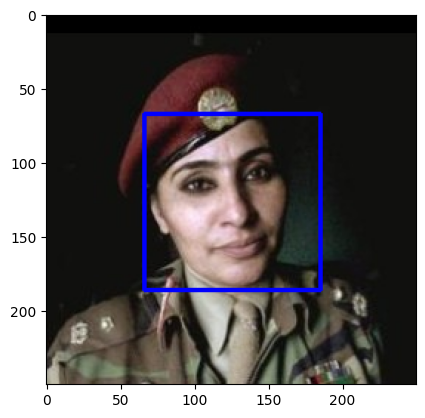

In [6]:
import cv2                
import matplotlib.pyplot as plt                        
%matplotlib inline                               

# extract pre-trained face detector
face_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_frontalface_alt.xml')

# load color (BGR) image
img = cv2.imread(human_files[3])
# convert BGR image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# find faces in image
faces = face_cascade.detectMultiScale(gray)

# print number of faces detected in the image
print('Number of faces detected:', len(faces))

# get bounding box for each detected face
for (x,y,w,h) in faces:
    # add bounding box to color image
    cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    
# convert BGR image to RGB for plotting
cv_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# display the image, along with bounding box
plt.imshow(cv_rgb)
plt.show()

Before using any of the face detectors, it is standard procedure to convert the images to grayscale.  The `detectMultiScale` function executes the classifier stored in `face_cascade` and takes the grayscale image as a parameter.  

In the above code, `faces` is a numpy array of detected faces, where each row corresponds to a detected face.  Each detected face is a 1D array with four entries that specifies the bounding box of the detected face.  The first two entries in the array (extracted in the above code as `x` and `y`) specify the horizontal and vertical positions of the top left corner of the bounding box.  The last two entries in the array (extracted here as `w` and `h`) specify the width and height of the box.

### Write a Human Face Detector

We can use this procedure to write a function that returns `True` if a human face is detected in an image and `False` otherwise.  This function, aptly named `face_detector`, takes a string-valued file path to an image as input and appears in the code block below.

In [7]:
# returns "True" if face is detected in image stored at img_path
def face_detector(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray)
    return len(faces) > 0

### (IMPLEMENTATION) Assess the Human Face Detector

__Question 1:__ Use the code cell below to test the performance of the `face_detector` function.  
- What percentage of the first 100 images in `human_files` have a detected human face?  
- What percentage of the first 100 images in `dog_files` have a detected human face? 

Ideally, we would like 100% of human images with a detected face and 0% of dog images with a detected face.  You will see that our algorithm falls short of this goal, but still gives acceptable performance.  We extract the file paths for the first 100 images from each of the datasets and store them in the numpy arrays `human_files_short` and `dog_files_short`.

__Answer:__ 

Out of the first 100 images in the human dataset, the face detector successfully detected a human face in 100% of the images. This indicates that the Haar cascade face detector performs very well when a clear, frontal human face is present.
Out of the first 100 images in the dog dataset, 12% were incorrectly classified as containing a human face. This suggests that the detector occasionally confuses certain dog facial features (such as eyes or snouts) for human faces.
Overall, while the detector is not perfect, it performs reasonably well: it detects nearly all human faces and only falsely identifies a small fraction of dog images as human faces. This level of performance is acceptable for use as a first step in the overall pipeline.

Accuracy was chosen as the evaluation metric because the problem is binary and the evaluation set is balanced, making accuracy a reliable and interpretable measure of the detector’s overall performance. 

In [8]:
human_files_short = human_files[:100]
dog_files_short = train_files[:100]
# Do NOT modify the code above this line.

## TODO: Test the performance of the face_detector algorithm 
## on the images in human_files_short and dog_files_short.

human_count = 0
dog_count = 0

for img_path in human_files_short:
    if face_detector(img_path):
        human_count += 1
        
for img_path in dog_files_short:
    if face_detector(img_path):
        dog_count += 1

print(f"Percentage of human images with detected face: {human_count} %")
print(f"Percentage of dog images with detected face: {dog_count} %")

Percentage of human images with detected face: 100 %
Percentage of dog images with detected face: 12 %


__Question 2:__ This algorithmic choice necessitates that we communicate to the user that we accept human images only when they provide a clear view of a face (otherwise, we risk having unneccessarily frustrated users!). In your opinion, is this a reasonable expectation to pose on the user? If not, can you think of a way to detect humans in images that does not necessitate an image with a clearly presented face?

__Answer:__

Requiring a clearly visible human face is not always a reasonable expectation, as users may upload images where faces are partially occluded, turned away, or too small. A more robust alternative would be to use deep learning–based human detection (for example, full‑body person detectors or CNNs trained on large human datasets), which can identify humans without relying on visible faces.


We suggest the face detector from OpenCV as a potential way to detect human images in your algorithm, but you are free to explore other approaches, especially approaches that make use of deep learning :).  Please use the code cell below to design and test your own face detection algorithm.  If you decide to pursue this _optional_ task, report performance on each of the datasets.

In [9]:
## (Optional) TODO: Report the performance of another  
## face detection algorithm on the LFW dataset
### Feel free to use as many code cells as needed.

---
<a id='step2'></a>
## Step 2: Detect Dogs

In this section, we use a pre-trained [ResNet-50](http://ethereon.github.io/netscope/#/gist/db945b393d40bfa26006) model to detect dogs in images.  Our first line of code downloads the ResNet-50 model, along with weights that have been trained on [ImageNet](http://www.image-net.org/), a very large, very popular dataset used for image classification and other vision tasks.  ImageNet contains over 10 million URLs, each linking to an image containing an object from one of [1000 categories](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).  Given an image, this pre-trained ResNet-50 model returns a prediction (derived from the available categories in ImageNet) for the object that is contained in the image.

In [10]:
from keras.applications.resnet50 import ResNet50

# define ResNet50 model
ResNet50_model = ResNet50(weights='imagenet')

2026-04-17 09:39:20.023354: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-17 09:39:20.036514: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-17 09:39:20.039442: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

102967424/102967424 [==============================] - 1s 0us/step


### Pre-process the Data

When using TensorFlow as backend, Keras CNNs require a 4D array (which we'll also refer to as a 4D tensor) as input, with shape

$$
(\text{nb_samples}, \text{rows}, \text{columns}, \text{channels}),
$$

where `nb_samples` corresponds to the total number of images (or samples), and `rows`, `columns`, and `channels` correspond to the number of rows, columns, and channels for each image, respectively.  

The `path_to_tensor` function below takes a string-valued file path to a color image as input and returns a 4D tensor suitable for supplying to a Keras CNN.  The function first loads the image and resizes it to a square image that is $224 \times 224$ pixels.  Next, the image is converted to an array, which is then resized to a 4D tensor.  In this case, since we are working with color images, each image has three channels.  Likewise, since we are processing a single image (or sample), the returned tensor will always have shape

$$
(1, 224, 224, 3).
$$

The `paths_to_tensor` function takes a numpy array of string-valued image paths as input and returns a 4D tensor with shape 

$$
(\text{nb_samples}, 224, 224, 3).
$$

Here, `nb_samples` is the number of samples, or number of images, in the supplied array of image paths.  It is best to think of `nb_samples` as the number of 3D tensors (where each 3D tensor corresponds to a different image) in your dataset!

In [11]:
from keras.preprocessing import image                  
from tqdm import tqdm

def path_to_tensor(img_path):
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        # Normalize the image tensor
        return np.expand_dims(x, axis=0)#.astype('float32')/255
    except IOError:
        print(f"Warning: Skipping corrupted image {img_path}")
        return None

def paths_to_tensor(img_paths):
    batch_tensors = []
    for img_path in img_paths:
        tensor = path_to_tensor(img_path)
        if tensor is not None:
            batch_tensors.append(tensor[0])
    return np.array(batch_tensors)

### Making Predictions with ResNet-50

Getting the 4D tensor ready for ResNet-50, and for any other pre-trained model in Keras, requires some additional processing.  First, the RGB image is converted to BGR by reordering the channels.  All pre-trained models have the additional normalization step that the mean pixel (expressed in RGB as $[103.939, 116.779, 123.68]$ and calculated from all pixels in all images in ImageNet) must be subtracted from every pixel in each image.  This is implemented in the imported function `preprocess_input`.  If you're curious, you can check the code for `preprocess_input` [here](https://github.com/fchollet/keras/blob/master/keras/applications/imagenet_utils.py).

Now that we have a way to format our image for supplying to ResNet-50, we are now ready to use the model to extract the predictions.  This is accomplished with the `predict` method, which returns an array whose $i$-th entry is the model's predicted probability that the image belongs to the $i$-th ImageNet category.  This is implemented in the `ResNet50_predict_labels` function below.

By taking the argmax of the predicted probability vector, we obtain an integer corresponding to the model's predicted object class, which we can identify with an object category through the use of this [dictionary](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a). 

In [12]:
from keras.applications.resnet50 import preprocess_input, decode_predictions

def ResNet50_predict_labels(img_path):
    # returns prediction vector for image located at img_path
    img = preprocess_input(path_to_tensor(img_path))
    return np.argmax(ResNet50_model.predict(img))

### Write a Dog Detector

While looking at the [dictionary](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), you will notice that the categories corresponding to dogs appear in an uninterrupted sequence and correspond to dictionary keys 151-268, inclusive, to include all categories from `'Chihuahua'` to `'Mexican hairless'`.  Thus, in order to check to see if an image is predicted to contain a dog by the pre-trained ResNet-50 model, we need only check if the `ResNet50_predict_labels` function above returns a value between 151 and 268 (inclusive).

We use these ideas to complete the `dog_detector` function below, which returns `True` if a dog is detected in an image (and `False` if not).

In [13]:
### returns "True" if a dog is detected in the image stored at img_path
def dog_detector(img_path):
    prediction = ResNet50_predict_labels(img_path)
    print(prediction)
    return ((prediction <= 268) & (prediction >= 151)) 

### (IMPLEMENTATION) Assess the Dog Detector

__Question 3:__ Use the code cell below to test the performance of your `dog_detector` function.  
- What percentage of the images in `human_files_short` have a detected dog?  
- What percentage of the images in `dog_files_short` have a detected dog?

__Answer:__ 

Percentage of human images with detected dog: 0 % 

Percentage of dog images with detected dog: 100 %

Accuracy was chosen as the evaluation metric because the problem is binary and the evaluation set is balanced, making accuracy a reliable and interpretable measure of the detector’s overall performance.

In [14]:
### TODO: Test the performance of the dog_detector function
### on the images in human_files_short and dog_files_short.
human_count = 0
dog_count = 0

# for img_path in human_files_short:
#     if dog_detector(img_path):
#         human_count += 1
        
# for img_path in dog_files_short:
#     if dog_detector(img_path):
#         dog_count += 1

for img_path in human_files_short:
    detected = dog_detector(img_path)
    print(f"Human image {img_path} detected: {detected}")
    if detected:
        human_count += 1

for img_path in dog_files_short:
    detected = dog_detector(img_path)
    print(f"Dog image {img_path} detected: {detected}")
    if detected:
        dog_count += 1

print(f"Percentage of human images with detected dog: {human_count} %")
print(f"Percentage of dog images with detected dog: {dog_count} %")

2026-04-17 09:39:25.365722: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600


1/1 [==============================] - 2s 2s/step
906
Human image ../../../data/lfw/Rick_Dinse/Rick_Dinse_0002.jpg detected: False
1/1 [==============================] - 0s 31ms/step
678
Human image ../../../data/lfw/JC_Chasez/JC_Chasez_0001.jpg detected: False
1/1 [==============================] - 0s 30ms/step
617
Human image ../../../data/lfw/Carlos_Menem/Carlos_Menem_0013.jpg detected: False
1/1 [==============================] - 0s 31ms/step
652
Human image ../../../data/lfw/Khatol_Mohammad_Zai/Khatol_Mohammad_Zai_0001.jpg detected: False
1/1 [==============================] - 0s 30ms/step
834
Human image ../../../data/lfw/George_W_Bush/George_W_Bush_0060.jpg detected: False
1/1 [==============================] - 0s 30ms/step
887
Human image ../../../data/lfw/Ray_Nagin/Ray_Nagin_0002.jpg detected: False
1/1 [==============================] - 0s 30ms/step
906
Human image ../../../data/lfw/Joschka_Fischer/Joschka_Fischer_0018.jpg detected: False
1/1 [==============================] 

1/1 [==============================] - 0s 33ms/step
740
Human image ../../../data/lfw/Brad_Johnson/Brad_Johnson_0001.jpg detected: False
1/1 [==============================] - 0s 33ms/step
906
Human image ../../../data/lfw/Glafcos_Clerides/Glafcos_Clerides_0001.jpg detected: False
1/1 [==============================] - 0s 33ms/step
715
Human image ../../../data/lfw/Edward_Belvin/Edward_Belvin_0001.jpg detected: False
1/1 [==============================] - 0s 32ms/step
906
Human image ../../../data/lfw/George_W_Bush/George_W_Bush_0049.jpg detected: False
1/1 [==============================] - 0s 32ms/step
429
Human image ../../../data/lfw/Jaymon_Crabb/Jaymon_Crabb_0001.jpg detected: False
1/1 [==============================] - 0s 34ms/step
834
Human image ../../../data/lfw/Gerhard_Schroeder/Gerhard_Schroeder_0062.jpg detected: False
1/1 [==============================] - 0s 32ms/step
906
Human image ../../../data/lfw/Raag_Singhal/Raag_Singhal_0001.jpg detected: False
1/1 [==============

1/1 [==============================] - 0s 30ms/step
219
Dog image /workspace/home/dog-project/dogimages/dogImages/train/053.Cocker_spaniel/Cocker_spaniel_03768.jpg detected: True
1/1 [==============================] - 0s 30ms/step
204
Dog image /workspace/home/dog-project/dogimages/dogImages/train/099.Lhasa_apso/Lhasa_apso_06646.jpg detected: True
1/1 [==============================] - 0s 32ms/step
220
Dog image /workspace/home/dog-project/dogimages/dogImages/train/009.American_water_spaniel/American_water_spaniel_00628.jpg detected: True
1/1 [==============================] - 0s 31ms/step
205
Dog image /workspace/home/dog-project/dogimages/dogImages/train/056.Dachshund/Dachshund_03935.jpg detected: True
1/1 [==============================] - 0s 31ms/step
153
Dog image /workspace/home/dog-project/dogimages/dogImages/train/082.Havanese/Havanese_05627.jpg detected: True
1/1 [==============================] - 0s 30ms/step
154
Dog image /workspace/home/dog-project/dogimages/dogImages/train

1/1 [==============================] - 0s 34ms/step
217
Dog image /workspace/home/dog-project/dogimages/dogImages/train/046.Cavalier_king_charles_spaniel/Cavalier_king_charles_spaniel_03305.jpg detected: True
1/1 [==============================] - 0s 34ms/step
200
Dog image /workspace/home/dog-project/dogimages/dogImages/train/017.Bearded_collie/Bearded_collie_01244.jpg detected: True
1/1 [==============================] - 0s 33ms/step
167
Dog image /workspace/home/dog-project/dogimages/dogImages/train/037.Brittany/Brittany_02614.jpg detected: True
1/1 [==============================] - 0s 34ms/step
227
Dog image /workspace/home/dog-project/dogimages/dogImages/train/011.Australian_cattle_dog/Australian_cattle_dog_00723.jpg detected: True
1/1 [==============================] - 0s 33ms/step
153
Dog image /workspace/home/dog-project/dogimages/dogImages/train/024.Bichon_frise/Bichon_frise_01771.jpg detected: True
1/1 [==============================] - 0s 31ms/step
243
Dog image /workspace/

In [15]:
print(f"Percentage of human images with detected dog: {human_count} %")
print(f"Percentage of dog images with detected dog: {dog_count} %")

Percentage of human images with detected dog: 0 %
Percentage of dog images with detected dog: 100 %


---
<a id='step3'></a>
## Step 3: Create a CNN to Classify Dog Breeds (from Scratch)

Now that we have functions for detecting humans and dogs in images, we need a way to predict breed from images.  In this step, you will create a CNN that classifies dog breeds.  You must create your CNN _from scratch_ (so, you can't use transfer learning _yet_!), and you must attain a test accuracy of at least 1%.  In Step 5 of this notebook, you will have the opportunity to use transfer learning to create a CNN that attains greatly improved accuracy.

Be careful with adding too many trainable layers!  More parameters means longer training, which means you are more likely to need a GPU to accelerate the training process.  Thankfully, Keras provides a handy estimate of the time that each epoch is likely to take; you can extrapolate this estimate to figure out how long it will take for your algorithm to train. 

We mention that the task of assigning breed to dogs from images is considered exceptionally challenging.  To see why, consider that *even a human* would have great difficulty in distinguishing between a Brittany and a Welsh Springer Spaniel.  

Brittany | Welsh Springer Spaniel
- | - 
<img src="images/Brittany_02625.jpg" width="100"> | <img src="images/Welsh_springer_spaniel_08203.jpg" width="200">

It is not difficult to find other dog breed pairs with minimal inter-class variation (for instance, Curly-Coated Retrievers and American Water Spaniels).  

Curly-Coated Retriever | American Water Spaniel
- | -
<img src="images/Curly-coated_retriever_03896.jpg" width="200"> | <img src="images/American_water_spaniel_00648.jpg" width="200">


Likewise, recall that labradors come in yellow, chocolate, and black.  Your vision-based algorithm will have to conquer this high intra-class variation to determine how to classify all of these different shades as the same breed.  

Yellow Labrador | Chocolate Labrador | Black Labrador
- | -
<img src="images/Labrador_retriever_06457.jpg" width="150"> | <img src="images/Labrador_retriever_06455.jpg" width="240"> | <img src="images/Labrador_retriever_06449.jpg" width="220">

We also mention that random chance presents an exceptionally low bar: setting aside the fact that the classes are slightly imabalanced, a random guess will provide a correct answer roughly 1 in 133 times, which corresponds to an accuracy of less than 1%.  

Remember that the practice is far ahead of the theory in deep learning.  Experiment with many different architectures, and trust your intuition.  And, of course, have fun! 

### Pre-process the Data

We rescale the images by dividing every pixel in every image by 255.

In [16]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Allow loading of truncated images

def image_generator(files, targets, batch_size):
    while True:
        batch_paths = np.random.choice(a=files, size=batch_size)
        batch_input = paths_to_tensor(batch_paths)
        valid_paths = [p for p in batch_paths if path_to_tensor(p) is not None]
        batch_indices = [np.where(files == img_path)[0][0] for img_path in valid_paths]
        batch_output = np.array([targets[index] for index in batch_indices])

        if len(batch_input) > 0:  # Ensure there is data to yield
            yield batch_input, batch_output

# Create generators for train, validation, and test datasets
train_generator = image_generator(train_files, train_targets, batch_size=64)
valid_generator = image_generator(valid_files, valid_targets, batch_size=64)
test_generator = image_generator(test_files, test_targets, batch_size=64)

### (IMPLEMENTATION) Model Architecture

Create a CNN to classify dog breed.  At the end of your code cell block, summarize the layers of your model by executing the line:
    
        model.summary()

We have imported some Python modules to get you started, but feel free to import as many modules as you need.  If you end up getting stuck, here's a hint that specifies a model that trains relatively fast on CPU and attains >1% test accuracy in 5 epochs:

![Sample CNN](images/sample_cnn.png)
           
__Question 4:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  If you chose to use the hinted architecture above, describe why you think that CNN architecture should work well for the image classification task.

__Answer:__ 

My architecture is similar to the one above, I added an extra convolutional layer with max pooling (now in total 4 instead of 3). The convolution layers help the model to learn patterns in the images. The architecture starts with convolutional layers with fewer filters and then on to convolutional layers with more filters. I did this so the model first learns more basic visual cues and later learns more detailed patterns to (hopefully) be able to identify different breeds. The MaxPooling reduces spatial size, which lowers computational requirements and adds translation invariance. The GlobalAveragePooling2D keeps the model more parameter efficient and decreases likelihood of overfitting. The final fully connected layer combines the learned features while regularizing to improve generalization.  

In [17]:
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dropout, Flatten, Dense
from keras.models import Sequential

model = Sequential()

### TODO: Define your architecture.
# Convolutional Layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 4
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Global Average Pooling Layer
model.add(GlobalAveragePooling2D())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Dropout layer to prevent overfitting

# Output Layer
model.add(Dense(133, activation='softmax'))  # num_classes is the number of dog breeds


model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

### Compile the Model

In [18]:
from keras.optimizers import Adam

# Set a smaller learning rate
adam = Adam(lr=0.001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

### (IMPLEMENTATION) Train the Model

Train your model in the code cell below.  Use model checkpointing to save the model that attains the best validation loss.

You are welcome to [augment the training data](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), but this is not a requirement. 

In [19]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau  

### TODO: specify the number of epochs that you would like to use to train the model.

epochs = 5

### Do NOT modify the code below this line.

# Add checkpoint to save the best model
checkpointer = ModelCheckpoint(filepath='saved_models/weights.best.from_scratch.hdf5',
                               verbose=1, save_best_only=True)

# ReduceLROnPlateau: This callback reduces the learning rate when a metric has stopped improving.
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5)

# Train the model
model.fit_generator(train_generator,
                    steps_per_epoch=len(train_files) // 32,
                    validation_data=valid_generator,
                    validation_steps=len(valid_files) // 32,
                    epochs=epochs,
                    callbacks=[checkpointer, reduce_lr],
                    verbose=2)

/tmp/ipykernel_136/183361258.py:17: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(train_generator,


Epoch 1/5


2026-04-17 09:39:48.397281: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7e8990f9efc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-17 09:39:48.397345: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-04-17 09:39:48.405358: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-17 09:39:48.543430: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from inf to 4.88477, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 154s - loss: 5.0845 - accuracy: 0.0089 - val_loss: 4.8848 - val_accuracy: 0.0096 - lr: 0.0010 - 154s/epoch - 739ms/step
Epoch 2/5


/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 4.88477 to 4.87970, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 146s - loss: 4.8815 - accuracy: 0.0118 - val_loss: 4.8797 - val_accuracy: 0.0084 - lr: 0.0010 - 146s/epoch - 703ms/step
Epoch 3/5

Epoch 3: val_loss improved from 4.87970 to 4.87710, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 147s - loss: 4.8761 - accuracy: 0.0121 - val_loss: 4.8771 - val_accuracy: 0.0126 - lr: 0.0010 - 147s/epoch - 706ms/step
Epoch 4/5

Epoch 4: val_loss improved from 4.87710 to 4.87516, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 140s - loss: 4.8744 - accuracy: 0.0100 - val_loss: 4.8752 - val_accuracy: 0.0072 - lr: 0.0010 - 140s/epoch - 671ms/step
Epoch 5/5

Epoch 5: val_loss improved from 4.87516 to 4.87454, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 134s - loss: 4.8704 - accuracy: 0.0115 - val_loss: 4.8745 - val_accuracy: 0.0150 - lr: 0.0010 - 134s/epoch - 645ms/ste

### Load the Model with the Best Validation Loss

In [20]:
model.load_weights('saved_models/weights.best.from_scratch.hdf5')

### Test the Model

Try out your model on the test dataset of dog images.  Ensure that your test accuracy is greater than 1%.

In [42]:
# Evaluate the model on the test data using `evaluate_generator`
test_loss, test_accuracy = model.evaluate_generator(test_generator, steps=len(test_files) // 32)

# Convert the accuracy to percentage
test_accuracy = test_accuracy * 100

print('Test accuracy: %.4f%%' % test_accuracy)



/tmp/ipykernel_136/1350986640.py:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  test_loss, test_accuracy = model.evaluate_generator(test_generator, steps=len(test_files) // 32)


Test accuracy: 1.1418%


---
<a id='step4'></a>
## Step 4: Use a CNN to Classify Dog Breeds

To reduce training time without sacrificing accuracy, we show you how to train a CNN using transfer learning.  In the following step, you will get a chance to use transfer learning to train your own CNN.

### Obtain Bottleneck Features

In [22]:
bottleneck_features = np.load('bottleneck_features/DogVGG16Data.npz')
train_VGG16 = bottleneck_features['train']
print(len(train_VGG16))
valid_VGG16 = bottleneck_features['valid']
print(len(valid_VGG16))
test_VGG16 = bottleneck_features['test']
# print(train_VGG16)

6680
835


### Model Architecture

The model uses the the pre-trained VGG-16 model as a fixed feature extractor, where the last convolutional output of VGG-16 is fed as input to our model.  We only add a global average pooling layer and a fully connected layer, where the latter contains one node for each dog category and is equipped with a softmax.

In [23]:
VGG16_model = Sequential()
VGG16_model.add(GlobalAveragePooling2D(input_shape=train_VGG16.shape[1:]))
VGG16_model.add(Dense(133, activation='softmax'))

VGG16_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 global_average_pooling2d_1  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 133)               68229     
                                                                 
Total params: 68229 (266.52 KB)
Trainable params: 68229 (266.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Compile the Model

In [24]:
VGG16_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

### Train the Model

In [25]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau  

checkpointer = ModelCheckpoint(filepath='saved_models/weights.best.VGG16.hdf5', 
                               verbose=1, save_best_only=True)

# # ReduceLROnPlateau: This callback reduces the learning rate when a metric has stopped improving.
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5)

VGG16_model.fit(train_VGG16, train_targets, 
          validation_data=(valid_VGG16, valid_targets),
          epochs=20, batch_size=20, callbacks=[checkpointer], verbose=1)

Epoch 1/20
322/334 [===========================>..] - ETA: 0s - loss: 8.0714 - accuracy: 0.2247
Epoch 1: val_loss improved from inf to 3.49878, saving model to saved_models/weights.best.VGG16.hdf5
334/334 [==============================] - 2s 5ms/step - loss: 7.9019 - accuracy: 0.2316 - val_loss: 3.4988 - val_accuracy: 0.4240
Epoch 2/20
322/334 [===========================>..] - ETA: 0s - loss: 2.2584 - accuracy: 0.5941
Epoch 2: val_loss improved from 3.49878 to 2.32902, saving model to saved_models/weights.best.VGG16.hdf5
334/334 [==============================] - 1s 3ms/step - loss: 2.2448 - accuracy: 0.5955 - val_loss: 2.3290 - val_accuracy: 0.5713
Epoch 3/20
321/334 [===========================>..] - ETA: 0s - loss: 1.2611 - accuracy: 0.7425
Epoch 3: val_loss improved from 2.32902 to 2.07572, saving model to saved_models/weights.best.VGG16.hdf5
334/334 [==============================] - 1s 3ms/step - loss: 1.2667 - accuracy: 0.7419 - val_loss: 2.0757 - val_accuracy: 0.6168
Epoch 4/

In [26]:
print(train_VGG16.shape, train_targets.shape)
print(valid_VGG16.shape, valid_targets.shape)
VGG16_model.summary()


(6680, 7, 7, 512) (6680, 133)
(835, 7, 7, 512) (835, 133)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 global_average_pooling2d_1  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 133)               68229     
                                                                 
Total params: 68229 (266.52 KB)
Trainable params: 68229 (266.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Load the Model with the Best Validation Loss

In [27]:
VGG16_model.load_weights('saved_models/weights.best.VGG16.hdf5')

### Test the Model

Now, we can use the CNN to test how well it identifies breed within our test dataset of dog images.  We print the test accuracy below.

In [28]:
# Test the model
test_predictions = VGG16_model.predict(test_VGG16, batch_size=20)
test_accuracy = 100 * np.mean(np.argmax(test_predictions, axis=1) == np.argmax(test_targets, axis=1))
print('Test accuracy: %.4f%%' % test_accuracy)

42/42 [==============================] - 0s 2ms/step
Test accuracy: 72.4880%


### Predict Dog Breed with the Model

In [29]:
from extract_bottleneck_features import *

def VGG16_predict_breed(img_path):
    # extract bottleneck features
    bottleneck_feature = extract_VGG16(path_to_tensor(img_path))
    # obtain predicted vector
    predicted_vector = VGG16_model.predict(bottleneck_feature)
    # return dog breed that is predicted by the model
    return dog_names[np.argmax(predicted_vector)]

---
<a id='step5'></a>
## Step 5: Create a CNN to Classify Dog Breeds (using Transfer Learning)

You will now use transfer learning to create a CNN that can identify dog breed from images.  Your CNN must attain at least 60% accuracy on the test set.

In Step 4, we used transfer learning to create a CNN using VGG-16 bottleneck features.  In this section, you must use the bottleneck features from a different pre-trained model.  To make things easier for you, we have pre-computed the features for all of the networks that are currently available in Keras:
- [VGG-19](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogVGG19Data.npz) bottleneck features
- [ResNet-50](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogResnet50Data.npz) bottleneck features
- [Inception](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogInceptionV3Data.npz) bottleneck features
- [Xception](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogXceptionData.npz) bottleneck features

The files are encoded as such:

    Dog{network}Data.npz
    
where `{network}`, in the above filename, can be one of `VGG19`, `Resnet50`, `InceptionV3`, or `Xception`.  Pick one of the above architectures, download the corresponding bottleneck features, and store the downloaded file in the `bottleneck_features/` folder in the repository.

### (IMPLEMENTATION) Obtain Bottleneck Features

In the code block below, extract the bottleneck features corresponding to the train, test, and validation sets by running the following:

    bottleneck_features = np.load('bottleneck_features/Dog{network}Data.npz')
    train_{network} = bottleneck_features['train']
    valid_{network} = bottleneck_features['valid']
    test_{network} = bottleneck_features['test']

In [30]:
### TODO: Obtain bottleneck features from another pre-trained CNN.

bottleneck_features = np.load('bottleneck_features/DogResnet50Data.npz')
train_ResNet = bottleneck_features['train']
valid_ResNet = bottleneck_features['valid']
test_ResNet = bottleneck_features['test']

print(train_ResNet.shape, valid_ResNet.shape, test_ResNet.shape)


(6680, 1, 1, 2048) (835, 1, 1, 2048) (836, 1, 1, 2048)


### (IMPLEMENTATION) Model Architecture

Create a CNN to classify dog breed.  At the end of your code cell block, summarize the layers of your model by executing the line:
    
        <your model's name>.summary()
   
__Question 5:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  Describe why you think the architecture is suitable for the current problem.

__Answer:__ 



In [31]:
### TODO: Define your architecture.
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

ResNet_model = Sequential()
ResNet_model.add(GlobalAveragePooling2D(input_shape=train_ResNet.shape[1:]))

ResNet_model.add(Dense(133, activation='softmax'))

ResNet_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_3 (Dense)             (None, 133)               272517    
                                                                 
Total params: 272517 (1.04 MB)
Trainable params: 272517 (1.04 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### (IMPLEMENTATION) Compile the Model

In [32]:
### TODO: Compile the model.
ResNet_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [33]:
!wget 'https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip'

--2026-04-17 09:52:33--  https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 16.15.0.216, 16.15.0.226, 52.219.194.0, ...
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|16.15.0.216|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1132023110 (1.1G) [application/zip]
Saving to: ‘dogImages.zip.2’

dogImages.zip.2     100%[===================>]   1.05G  65.0MB/s    in 19s     

2026-04-17 09:52:53 (57.0 MB/s) - ‘dogImages.zip.2’ saved [1132023110/1132023110]



In [34]:
import zipfile as zf
files = zf.ZipFile("dogImages.zip", 'r')
files.extractall('dogimages')
files.close()

In [35]:
!cp -rp /workspace/home/dog-project/dogimages/dogImages /workspace/home/dog-project/dog_images


### (IMPLEMENTATION) Train the Model

Train your model in the code cell below.  Use model checkpointing to save the model that attains the best validation loss.  

You are welcome to [augment the training data](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), but this is not a requirement. 

In [36]:
### TODO: Train the model.

from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau  

checkpointer = ModelCheckpoint(filepath='saved_models/weights.best.ResNet_model', 
                               verbose=1, save_best_only=True)

ResNet_model.fit(train_ResNet, train_targets, 
          validation_data=(valid_ResNet, valid_targets),
          epochs=20, batch_size=20, callbacks=[checkpointer], verbose=1)

Epoch 1/20
319/334 [===========================>..] - ETA: 0s - loss: 1.6609 - accuracy: 0.5914
Epoch 1: val_loss improved from inf to 0.80481, saving model to saved_models/weights.best.ResNet_model
INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


334/334 [==============================] - 2s 5ms/step - loss: 1.6259 - accuracy: 0.5981 - val_loss: 0.8048 - val_accuracy: 0.7509
Epoch 2/20
330/334 [============================>.] - ETA: 0s - loss: 0.4406 - accuracy: 0.8648
Epoch 2: val_loss improved from 0.80481 to 0.68428, saving model to saved_models/weights.best.ResNet_model
INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


334/334 [==============================] - 1s 4ms/step - loss: 0.4417 - accuracy: 0.8647 - val_loss: 0.6843 - val_accuracy: 0.8012
Epoch 3/20
332/334 [============================>.] - ETA: 0s - loss: 0.2618 - accuracy: 0.9184
Epoch 3: val_loss improved from 0.68428 to 0.64619, saving model to saved_models/weights.best.ResNet_model
INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


334/334 [==============================] - 1s 4ms/step - loss: 0.2626 - accuracy: 0.9183 - val_loss: 0.6462 - val_accuracy: 0.8000
Epoch 4/20
316/334 [===========================>..] - ETA: 0s - loss: 0.1679 - accuracy: 0.9495
Epoch 4: val_loss improved from 0.64619 to 0.60720, saving model to saved_models/weights.best.ResNet_model
INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


INFO:tensorflow:Assets written to: saved_models/weights.best.ResNet_model/assets


334/334 [==============================] - 1s 4ms/step - loss: 0.1681 - accuracy: 0.9494 - val_loss: 0.6072 - val_accuracy: 0.8240
Epoch 5/20
330/334 [============================>.] - ETA: 0s - loss: 0.1172 - accuracy: 0.9653
Epoch 5: val_loss did not improve from 0.60720
334/334 [==============================] - 1s 3ms/step - loss: 0.1171 - accuracy: 0.9656 - val_loss: 0.6587 - val_accuracy: 0.8156
Epoch 6/20
334/334 [==============================] - ETA: 0s - loss: 0.0783 - accuracy: 0.9783
Epoch 6: val_loss did not improve from 0.60720
334/334 [==============================] - 1s 3ms/step - loss: 0.0783 - accuracy: 0.9783 - val_loss: 0.6605 - val_accuracy: 0.8108
Epoch 7/20
314/334 [===========================>..] - ETA: 0s - loss: 0.0576 - accuracy: 0.9852
Epoch 7: val_loss did not improve from 0.60720
334/334 [==============================] - 1s 3ms/step - loss: 0.0585 - accuracy: 0.9849 - val_loss: 0.6433 - val_accuracy: 0.8228
Epoch 8/20
331/334 [===========================

### (IMPLEMENTATION) Load the Model with the Best Validation Loss

In [37]:
### TODO: Load the model weights with the best validation loss.

ResNet_model.load_weights('saved_models/weights.best.ResNet_model')

2026-04-17 09:54:07.861385: W tensorflow/core/util/tensor_slice_reader.cc:98] Could not open saved_models/weights.best.ResNet_model: FAILED_PRECONDITION: saved_models/weights.best.ResNet_model; Is a directory: perhaps your file is in a different file format and you need to use a different restore operator?


### (IMPLEMENTATION) Test the Model

Try out your model on the test dataset of dog images. Ensure that your test accuracy is greater than 60%.

In [38]:
### TODO: Calculate classification accuracy on the test dataset.

# Test the model
test_predictions = ResNet_model.predict(test_ResNet, batch_size=20)
test_accuracy = 100 * np.mean(np.argmax(test_predictions, axis=1) == np.argmax(test_targets, axis=1))
print('Test accuracy: %.4f%%' % test_accuracy)

42/42 [==============================] - 0s 2ms/step
Test accuracy: 81.4593%


### (IMPLEMENTATION) Predict Dog Breed with the Model

Write a function that takes an image path as input and returns the dog breed (`Affenpinscher`, `Afghan_hound`, etc) that is predicted by your model.  

Similar to the analogous function in Step 5, your function should have three steps:
1. Extract the bottleneck features corresponding to the chosen CNN model.
2. Supply the bottleneck features as input to the model to return the predicted vector.  Note that the argmax of this prediction vector gives the index of the predicted dog breed.
3. Use the `dog_names` array defined in Step 0 of this notebook to return the corresponding breed.

The functions to extract the bottleneck features can be found in `extract_bottleneck_features.py`, and they have been imported in an earlier code cell.  To obtain the bottleneck features corresponding to your chosen CNN architecture, you need to use the function

    extract_{network}
    
where `{network}`, in the above filename, should be one of `VGG19`, `Resnet50`, `InceptionV3`, or `Xception`.

In [39]:
### TODO: Write a function that takes a path to an image as input
### and returns the dog breed that is predicted by the model.

dog_names = [
    item.split("/")[-2].split(".", 1)[1]
    for item in sorted(glob("/data/dog_images/train/*/"))
]

def ResNet50_predict_breed(img_path):
    """
    Predict dog breed for an image using ResNet-50 bottleneck features.
    """
    # 1. Extract ResNet-50 bottleneck features
    bottleneck_feature = extract_Resnet50(path_to_tensor(img_path))
    
    # 2. Predict probabilities for each dog breed
    predicted_vector = ResNet_model.predict(bottleneck_feature)
    
    # 3. Return the corresponding dog breed name
    breed = dog_names[np.argmax(predicted_vector)]
    
    return breed


---
<a id='step6'></a>
## Step 6: Write your Algorithm

Write an algorithm that accepts a file path to an image and first determines whether the image contains a human, dog, or neither.  Then,
- if a __dog__ is detected in the image, return the predicted breed.
- if a __human__ is detected in the image, return the resembling dog breed.
- if __neither__ is detected in the image, provide output that indicates an error.

You are welcome to write your own functions for detecting humans and dogs in images, but feel free to use the `face_detector` and `dog_detector` functions developed above.  You are __required__ to use your CNN from Step 5 to predict dog breed.  

A sample image and output for our algorithm is provided below, but feel free to design your own user experience!

![Sample Human Output](images/sample_human_2.png)

This photo looks like an Afghan Hound.
### (IMPLEMENTATION) Write your Algorithm

In [40]:
### TODO: Write your algorithm.
### Feel free to use as many code cells as needed.
def dog_breed_alg(img_path):
    
    """
    Accepts an image path and determines whether it contains a dog, human, or neither.
    Prints the appropriate output and predicted dog breed (using Step 5 model).
    """
    
    if dog_detector(img_path):
        print("Dog detected!")
        print("Breed:", ResNet50_predict_breed(img_path))

    elif face_detector(img_path):
        print("Human detected!")
        print("Breed:", ResNet50_predict_breed(img_path))

    else:
        print("Error: No dog or human detected in the image!")



---
<a id='step7'></a>
## Step 7: Test Your Algorithm

In this section, you will take your new algorithm for a spin!  What kind of dog does the algorithm think that __you__ look like?  If you have a dog, does it predict your dog's breed accurately?  If you have a cat, does it mistakenly think that your cat is a dog?

### (IMPLEMENTATION) Test Your Algorithm on Sample Images!

Test your algorithm at least six images on your computer.  Feel free to use any images you like.  Use at least two human and two dog images.  

__Question 6:__ Is the output better than you expected :) ?  Or worse :( ?  Provide at least three possible points of improvement for your algorithm.

__Answer:__ 

The output does detect whether it is a human or a dog correctly. The dog breeds are a bit more difficult, half of the outcomes are correct. The incorrect dog breeds, are dogs that visually look similar. As a human, you can easily tell the difference, however my CNN fnds this challenging. 

Improvements:
- Increase the size and diversity of training data 
- Improving the model’s ability to generalize through better regularization or architecture choices
- Apply data augmentation during training to help the model become more robust to variations in pose, lighting and background.

In [41]:
## TODO: Execute your algorithm from Step 6 on
## at least 6 images on your computer.
## Feel free to use as many code cells as needed.


dog_breed_alg("Beagle_600.jpg")

dog_breed_alg("German_Shepherd.jpg")

dog_breed_alg("Rottweiler.jpg")

dog_breed_alg("Taylor_Swift.jpg")

dog_breed_alg("Albert_Einstein.webp")

dog_breed_alg("Bulldog.jpg")

1/1 [==============================] - 0s 72ms/step
162
Dog detected!
1/1 [==============================] - 0s 55ms/step
Breed: Beagle
1/1 [==============================] - 0s 33ms/step
235
Dog detected!
1/1 [==============================] - 0s 27ms/step
Breed: German_shepherd_dog
1/1 [==============================] - 0s 33ms/step
165
Dog detected!


1/1 [==============================] - 0s 28ms/step
Breed: Black_and_tan_coonhound
1/1 [==============================] - 0s 32ms/step
903
Human detected!


1/1 [==============================] - 0s 26ms/step
Breed: Alaskan_malamute
1/1 [==============================] - 0s 32ms/step
650
Human detected!
1/1 [==============================] - 0s 29ms/step
Breed: Lowchen
1/1 [==============================] - 0s 33ms/step
243
Dog detected!
1/1 [==============================] - 0s 27ms/step
Breed: American_staffordshire_terrier
